# 1.3.1

Задайте 4 точки в трехмерном пространстве, рассчитайте между ними расстояния по описанным в примере выше метрикам. Отобразите точки в трехмерном пространстве.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

In [8]:
points = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [2, 5, 1]
])

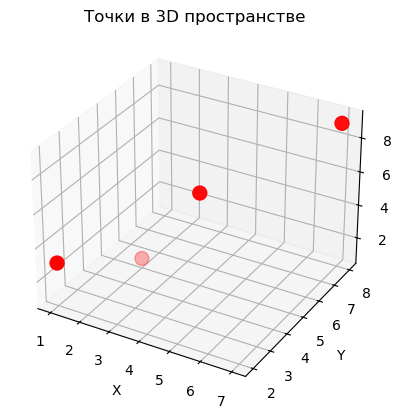

In [9]:
fig = plt.axes(projection='3d')
fig.scatter3D(points[:,0], points[:,1], points[:,2], c='red', s=100)
fig.set_xlabel('X')
fig.set_ylabel('Y')
fig.set_zlabel('Z')
plt.title("Точки в 3D пространстве")
plt.show()

In [10]:
A, B = points[0], points[1]

In [11]:
print(f"Точка A: {A}, Точка B: {B}")
print(f"Евклидово расстояние: {distance.euclidean(A, B)}")
print(f"Квадрат Евклидова расстояния: {distance.sqeuclidean(A, B)}")
print(f"Расстояние Чебышева: {distance.chebyshev(A, B)}")
print(f"Расстояние Хемминга (Манхэттенское): {distance.cityblock(A, B)}")

Точка A: [1 2 3], Точка B: [4 5 6]
Евклидово расстояние: 5.196152422706632
Квадрат Евклидова расстояния: 27.0
Расстояние Чебышева: 3
Расстояние Хемминга (Манхэттенское): 9


# 2.3.1

Для предыдущего примера поэкспериментируйте с параметрами классификатора:

    1. Установите другое количество ближайших соседей (k = 1, 5, 10).
    2. Установите размер тестовой выборки 15% от всего датасета.
    3. Постройте графики и оцените качество моделей, проанализируйте результаты.

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [13]:
iris = sns.load_dataset("iris")

X = iris.drop('species', axis=1)
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} примеров")
print(f"Тестовая выборка: {X_test.shape[0]} примеров")
X_train.head()

Обучающая выборка: 127 примеров
Тестовая выборка: 23 примеров


,sepal_length,sepal_width,petal_length,petal_width
128,6.4,2.8,5.6,2.1
131,7.9,3.8,6.4,2.0
145,6.7,3.0,5.2,2.3
108,6.7,2.5,5.8,1.8
143,6.8,3.2,5.9,2.3


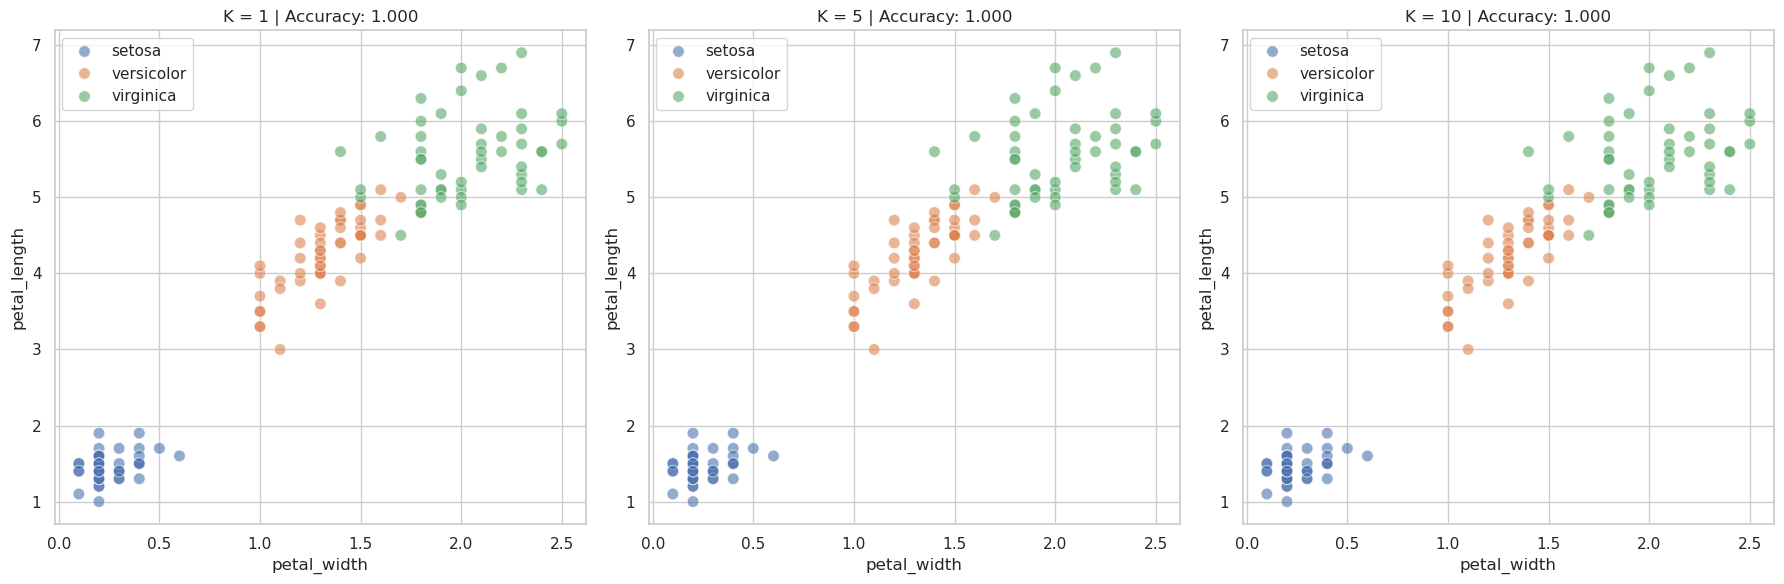

In [14]:
ks = [1, 5, 10]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, K in enumerate(ks):
    model = KNeighborsClassifier(n_neighbors=K)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    ax = axes[i]
    sns.scatterplot(x='petal_width', y='petal_length', data=iris, 
                    hue='species', s=70, alpha=0.6, ax=ax)
    
    test_indices = y_test.index
    errors_mask = (y_test != y_pred).values
    
    if errors_mask.any():
        ax.scatter(X_test.iloc[errors_mask, 3], X_test.iloc[errors_mask, 2], 
                   facecolors='none', edgecolors='red', s=200, linewidth=2, label='Ошибки')
    
    ax.set_title(f'K = {K} | Accuracy: {acc:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

# 3.3.2

Определите набор признаков человека, по аналогии из РТ 1, – например, цвет глаз и конвертируйте его в матрицу признаков.

In [15]:
from sklearn.feature_extraction import DictVectorizer

In [16]:
data_dict = [
    {"цвет_глаз": "голубой", "цвет_волос": "черный"},
    {"цвет_глаз": "зеленый", "цвет_волос": "рыжий"},
    {"цвет_глаз": "голубой", "цвет_волос": "блондин"},
    {"цвет_глаз": "карий", "цвет_волос": "шатен"}
]

In [17]:
dict_vectorizer = DictVectorizer(sparse=False)

In [18]:
feature_matrix = dict_vectorizer.fit_transform(data_dict)

In [19]:
print("Матрица признаков:")
print(feature_matrix)

Матрица признаков:
[[0. 0. 1. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1.]]


In [20]:
print("\nНазвания признаков в матрице:")
print(dict_vectorizer.get_feature_names_out())


Названия признаков в матрице:
['цвет_волос=блондин' 'цвет_волос=рыжий' 'цвет_волос=черный'
 'цвет_волос=шатен' 'цвет_глаз=голубой' 'цвет_глаз=зеленый'
 'цвет_глаз=карий']
